## Goodreads Choice Awards 2025 Web Scraping & Analysis
This analysis includes web scraping the books from the results of the readers' favorite books of 2025 on Goodreads. 

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import json
import base64
import time
import re
from bs4 import BeautifulSoup
from playwright.async_api import async_playwright, TimeoutError as PlaywrightTimeout

In [2]:
# list of genres included in the awards
GENRE = list(["fiction-books", "historical-fiction-books", "mystery-thriller-books", 
                  "romance-books", "romantasy-books", "fantasy-books", "science-fiction-books", 
                  "horror-books", "debut-novel", "audio-books", "ya-fantasy-and-science-fiction-books",
                  "ya-fiction-books", "nonfiction-books", "memoir-books", "history-bio-books"])

In [3]:
# defining folder paths 
DATA_DIR = "data"
BOOKS_DIR = os.path.join(DATA_DIR, "books")

### `get_html`
This function scrapes a webpage via Playwright and returns the inner HTML of a specific element targeted by a CSS selector. 

Playwright is used because Goodreads pages are JavaScript-rendered, meaning the content isn't available in a simple http request.

In [4]:
async def get_html(url, selector, sleep=5, retries=3):
    """
    scrapes html given a url and a CSS selector of the element to extract HTML from. 
    includes the number of retries if scraping fails and the base number of secs to 
    wait between retries.
    """
    html = None
    for i in range(1, retries+1): # run retries if scraping fails
        time.sleep(sleep * i) # pauses program each time we scrape
        
        try:
            async with async_playwright() as p:
                browser = await p.firefox.launch() # launches browser
                page = await browser.new_page() # creating new page in our browser
                await page.goto(url) # navigate to url
                print(await page.title())
                html = await page.inner_html(selector) # extract html
        
        except PlaywrightTimeout:
            print(f"Timeout error on {url}") # selector not found or page too slow
            continue
        else:
            break # scrape succeeded, exit retry loop
    return html

### `scrape_book`
This function scrapes all nominated books for a given genre and saves each book's HTML locally for later parsing and analysis. The function is called once per genre and follows this flow:
1. Builds the genre's award page URL
2. Extracts all nominated book link from the poll section
3. Visits each individual book page and saves the HTML locally

The books are saved using the book's ID and title as the filename. If the book has alreayd been scraped, it is skipped to avoid redundancy.

In [5]:
async def scrape_book(genre):
    """
    scrapes list of books for a given genre and saves each book page locally
    """
    # build url for the genre's choice awards page
    url = f"https://www.goodreads.com/choiceawards/readers-favorite-{genre}-2025"

    # get html of the poll section containing all nominated books
    html = await get_html(url, "div.pollContents")

    soup = BeautifulSoup(html)
    links = soup.find_all("a", class_='pollAnswer__bookLink') # find all book links
    books = [l["href"] for l in links] # extract href
    book_pages = [f"https://www.goodreads.com{l}" for l in books] # build full urls for each book

    # saves each book using last part of url as filename
    for url in book_pages:
        save_path = os.path.join(BOOKS_DIR, url.split("/")[-1].split("?")[0])
        if os.path.exists(save_path):
            continue

        html = await get_html(url, "div.BookPage__mainContent")
        with open(save_path, "w+", encoding="utf-8") as f:
            f.write(html)

In [6]:
# use this to scrape each genre page; it will take awhile to scrape each page
# for genre in GENRE:
#     await scrape_book(genre)

In [7]:
# shows the list of all saved book files
books_file = os.listdir(BOOKS_DIR)
books_file

['.ipynb_checkpoints',
 '176444106-abundance',
 '182484370-a-witch-s-guide-to-magical-innkeeping',
 '193388653-nobody-s-girl',
 '198190200-i-think-we-ve-been-here-before',
 '198563691-original-sins',
 '199531917-the-survivor-wants-to-die-at-the-end',
 '199534697-black-in-blues',
 '200982339-under-the-same-stars',
 '203578826-the-cure-for-women',
 '203578847-wind-and-truth',
 '203747797-sisters-in-science',
 '207611566-witchcraft-for-wayward-girls',
 '208840291-the-serviceberry',
 '209439446-onyx-storm',
 '210134467-the-songbird-the-heart-of-stone',
 '210191671-katabasis',
 '210384823-shroud',
 '210395729-our-infinite-fates',
 '210411871-the-sirens',
 '211003699-propaganda-girls',
 '211003924-breath-of-the-dragon',
 '211003941-realm-of-ice-and-sky',
 '211004064-the-jfk-conspiracy',
 '211004089-wild-dark-shore',
 '211004123-beautiful-ugly',
 '211004176-the-river-has-roots',
 '211004190-when-the-moon-hits-your-eye',
 '211004954-needy-little-things',
 '211025454-the-stolen-queen',
 '211096

### `get_book_to_genre`
This function builds a dictionary mapping each book ID to its Goodreads Choice Award genre. This is necessary because all book HTML files are saved in a single folder with 
no genre information in the filename.

The function scrapes each genre's awards page to extract the book links and map 
them to their genre. To avoid redundant scraping, the dictionary is saved to a 
JSON file after the first run and loaded from there on subsequent calls.

In [8]:
async def get_book_to_genre(genres):
    """
    builds dictionary mapping each book to its genre by scraping each 
    genre's awards page. saves to json so you don't have to scrape again.
    """
    # load from file if it already exists
    if os.path.exists("data/book_to_genre.json"):
        with open("data/book_to_genre.json", "r") as f:
            return json.load(f)
    
    # otherwise scrape and save
    book_to_genre = {}
    for genre in genres:
        url = f"https://www.goodreads.com/choiceawards/readers-favorite-{genre}-2025"
        html = await get_html(url, "div.pollContents")
        soup = BeautifulSoup(html)
        links = soup.find_all("a", class_='pollAnswer__bookLink')
        books = [l["href"].split("/")[-1].split("?")[0] for l in links]
        for book in books:
            book_to_genre[book] = genre
    
    # save once after all genres are scraped
    with open("data/book_to_genre.json", "w") as f:
        json.dump(book_to_genre, f)
    
    return book_to_genre

book_to_genre = await get_book_to_genre(GENRE)

### `parse_book`

This function parses a locally saved HTML file for a single book and extracts key metadata using BeautifulSoup. Fields are set to `None` if not found on the page, making the function robust to missing or inconsistent data across different book pages. This function returns a dictionary containing the following fields:
- title: book title
- author: book author name
- rating: average Goodreads rating
- num_ratings: total number of ratings
- num_reviews: total number of reviews
- pages: number of pages and the format (ex. 123 pages, Paperback)

### Creating the Dataframe

Once all book HTML files have been scraped and saved locally, we parse each file 
using `parse_book()` and combine the results into a single pandas dataframe for 
analysis.

For each book we also attach:
- **`book_id`** — the filename, used as a unique identifier
- **`genre`** — looked up from the `book_to_genre` dictionary built earlier.

If a book is not found in the dictionary it is labeled `"unknown"`

In [9]:
def parse_book(filepath):
    """
    parses a locally saved HTML file for a single book and exracts key metadata.
    """
    # read html file
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        html = f.read()
        
    # parse using BeautifulSoup
    soup = BeautifulSoup(html, "html.parser")
    
    # extract using CSS selector
    title = soup.find("h1", {"data-testid": "bookTitle"})
    author = soup.find("span", class_="ContributorLink__name")
    rating = soup.find("div", class_="RatingStatistics__rating")
    num_ratings = soup.find("span", {"data-testid": "ratingsCount"})
    num_reviews = soup.find("span", {"data-testid": "reviewsCount"})
    pages = soup.find("p", {"data-testid": "pagesFormat"})

    
    return {
        "title": title.text.strip() if title else None,
        "author": author.text.strip() if author else None,
        "rating": rating.text.strip() if rating else None,
        "num_ratings": num_ratings.text.strip() if num_ratings else None,
        "num_reviews": num_reviews.text.strip() if num_reviews else None,
        "pages": pages.text.strip() if pages else None
    }

In [10]:
rows = [] # store parsed book data

for filename in os.listdir(BOOKS_DIR):
    if filename.startswith("."): # skip hidden folders
        continue
        
    filepath = os.path.join(BOOKS_DIR, filename) # build full path to file
    try:
        book = parse_book(filepath) # parse book html
        book["book_id"] = filename # add filename as book ID
        book["genre"] = book_to_genre.get(filename, "unknown") # look up genre from dictionary
        rows.append(book) # add to list
        
    except Exception as e:
        print(f"Error parsing {filename}: {e}")

df = pd.DataFrame(rows)
df.head()

,title,author,rating,num_ratings,num_reviews,pages,book_id,genre
0,Abundance,Ezra Klein,3.92,"43,454 ratings","5,605 reviews","304 pages, Hardcover",176444106-abundance,nonfiction-books
1,A Witch's Guide to Magical Innkeeping,Sangu Mandanna,3.95,"94,086 ratings","15,077 reviews","352 pages, Paperback",182484370-a-witch-s-guide-to-magical-innkeeping,romantasy-books
2,Nobody's Girl: A Memoir of Surviving Abuse and...,Virginia Roberts Giuffre,4.55,"63,156 ratings","8,299 reviews","367 pages, Hardcover",193388653-nobody-s-girl,memoir-books
3,I Think We've Been Here Before,Suzy Krause,4.00,"6,930 ratings",822 reviews,"317 pages, Paperback",198190200-i-think-we-ve-been-here-before,science-fiction-books
4,Original Sins: The (Mis)education of Black and...,Eve L. Ewing,4.47,"1,761 ratings",356 reviews,"400 pages, Hardcover",198563691-original-sins,history-bio-books


### Basic Cleaning
Before analysis, several columns need to be cleaned and converted to the correct 
data types.

- **`num_ratings` and `num_reviews`** are extracted as strings (e.g. `"94,789 ratings"`). All non-digit characters were stripped and converted to float
- **`pages`** contains both the page count and format in one string (e.g. `" 123 pages, Paperback"`). 
We split this into two separate columns — `pages` as an integer and `format` as a string.
- **`rating`** is extracted as a string and needs to be converted to a float for numerical analysis.

In [11]:
def extract_number(text):
    """
    Extracts a numeric value from a string by removing all non-digit characters.
    Returns None if the input is None or NaN.
    """
    if text is None or pd.isna(text):
        return None
    return int(re.sub(r"[^\d]", "", str(text)))

df["num_ratings"] = df["num_ratings"].apply(extract_number)
df["num_reviews"] = df["num_reviews"].apply(extract_number)

In [12]:
# splits "pages" column into number of pages and the format (hardcover, paperback, etc.)
df["format"] = df["pages"].apply(lambda x: x.split(",")[-1].strip() if pd.notna(x) and "," in x else x)
df["pages"] = df["pages"].apply(lambda x: int(re.search(r"\d+", x).group()) if pd.notna(x) and re.search(r"\d+", x) else None)

In [13]:
# convert rating to float
df["rating"] = pd.to_numeric(df["rating"])

### Exploratory Data Exploration
Before diving into analysis, we first inspect the dataframe to understand its 
structure, data types, missing values, and summary statistics.

- 291 books scraped across all genres
- most columns have 1 missing value; likely a book failed to scrape properly
- pages has 10 missing values; this may be from books in audibook formats

In [14]:
display(df.shape)  # number of rows and columns
display(df.info()) # data types
display(df.isnull().sum())  # missing data
display(df.head()) # first 5 rows 
display(df.describe(include='all').round(2)) # summary stats of all columns 

(291, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        290 non-null    object 
 1   author       290 non-null    object 
 2   rating       290 non-null    float64
 3   num_ratings  290 non-null    float64
 4   num_reviews  290 non-null    float64
 5   pages        281 non-null    float64
 6   book_id      291 non-null    object 
 7   genre        291 non-null    object 
 8   format       290 non-null    object 
dtypes: float64(4), object(5)
memory usage: 20.6+ KB


None

title           1
author          1
rating          1
num_ratings     1
num_reviews     1
pages          10
book_id         0
genre           0
format          1
dtype: int64

,title,author,rating,num_ratings,num_reviews,pages,book_id,genre,format
0,Abundance,Ezra Klein,3.92,43454.0,5605.0,304.0,176444106-abundance,nonfiction-books,Hardcover
1,A Witch's Guide to Magical Innkeeping,Sangu Mandanna,3.95,94086.0,15077.0,352.0,182484370-a-witch-s-guide-to-magical-innkeeping,romantasy-books,Paperback
2,Nobody's Girl: A Memoir of Surviving Abuse and...,Virginia Roberts Giuffre,4.55,63156.0,8299.0,367.0,193388653-nobody-s-girl,memoir-books,Hardcover
3,I Think We've Been Here Before,Suzy Krause,4.00,6930.0,822.0,317.0,198190200-i-think-we-ve-been-here-before,science-fiction-books,Paperback
4,Original Sins: The (Mis)education of Black and...,Eve L. Ewing,4.47,1761.0,356.0,400.0,198563691-original-sins,history-bio-books,Hardcover


,title,author,rating,num_ratings,num_reviews,pages,book_id,genre,format
count,290,290,290.00,290.00,290.00,281.00,291,291,290
unique,276,265,NaN,NaN,NaN,NaN,291,15,6
top,Alchemised,Ali Hazelwood,NaN,NaN,NaN,NaN,176444106-abundance,nonfiction-books,Hardcover
freq,2,3,NaN,NaN,NaN,NaN,1,20,224
mean,NaN,NaN,4.05,95281.62,13266.78,378.07,NaN,NaN,NaN
std,NaN,NaN,0.25,196715.15,25753.21,159.86,NaN,NaN,NaN
min,NaN,NaN,3.46,910.00,208.00,7.00,NaN,NaN,NaN
25%,NaN,NaN,3.85,8845.50,1690.00,309.00,NaN,NaN,NaN
50%,NaN,NaN,4.04,29973.00,4663.50,367.00,NaN,NaN,NaN
75%,NaN,NaN,4.23,93784.50,12050.00,435.00,NaN,NaN,NaN


## Which genre has the highest rated nominees on average?
Started by looking at the average rating of nominated books across all genres. 
This gives us a high level view of which genres tend to produce the most 
critically acclaimed books according to Goodreads readers.
The top 5 highest rated genres are:
1. audiobooks
2. memoirs
3. history-bio
4. non-fiction
5. romantasy
- Among books that are both highly rated and widely read, what do they have in common?

In [15]:
# get top 5 highest rated genres
top_genres = df.groupby("genre")["rating"].mean().round(2).sort_values(ascending=False).head(5).index
display(top_genres)

# filter df for only top genres
top_df = df[df["genre"].isin(top_genres)]
display(top_df.head())

Index(['audio-books', 'memoir-books', 'history-bio-books', 'nonfiction-books',
       'romantasy-books'],
      dtype='object', name='genre')

,title,author,rating,num_ratings,num_reviews,pages,book_id,genre,format
0,Abundance,Ezra Klein,3.92,43454.0,5605.0,304.0,176444106-abundance,nonfiction-books,Hardcover
1,A Witch's Guide to Magical Innkeeping,Sangu Mandanna,3.95,94086.0,15077.0,352.0,182484370-a-witch-s-guide-to-magical-innkeeping,romantasy-books,Paperback
2,Nobody's Girl: A Memoir of Surviving Abuse and...,Virginia Roberts Giuffre,4.55,63156.0,8299.0,367.0,193388653-nobody-s-girl,memoir-books,Hardcover
4,Original Sins: The (Mis)education of Black and...,Eve L. Ewing,4.47,1761.0,356.0,400.0,198563691-original-sins,history-bio-books,Hardcover
6,Black in Blues: How a Color Tells the Story of...,Imani Perry,4.28,2408.0,531.0,256.0,199534697-black-in-blues,nonfiction-books,Hardcover


### Within the highest rated genres, do books with more ratings also have higher scores?
Now that we've identified the top 5 highest rated genres, we dig deeper to 
understand whether popularity drives quality within those genres, or whether 
the two are unrelated.

I used a scatter plot to visualize the relationship between number of ratings 
(popularity) and rating score for each of the top genres, and then calculate 
the correlation coefficient to quantify the relationship.

A correlation close to `1` means more ratings = higher score, close to `-1` 
means more ratings = lower score, and close to `0` means no relationship.

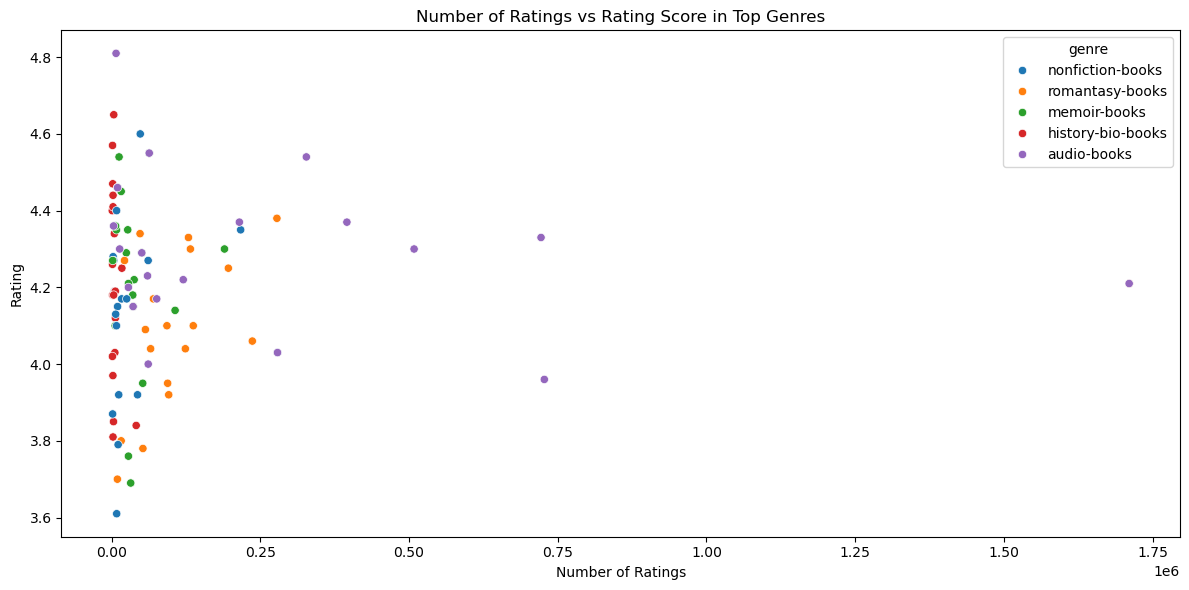

num_ratings    rating
genre                                               
audio-books       num_ratings     1.000000 -0.206189
                  rating         -0.206189  1.000000
history-bio-books num_ratings     1.000000 -0.351446
                  rating         -0.351446  1.000000
memoir-books      num_ratings     1.000000 -0.046631
                  rating         -0.046631  1.000000
nonfiction-books  num_ratings     1.000000  0.104819
                  rating          0.104819  1.000000
romantasy-books   num_ratings     1.000000  0.227651
                  rating          0.227651  1.000000

In [16]:
# scatter plot of num_ratings vs rating for top genres
plt.figure(figsize=(12, 6))
sns.scatterplot(data=top_df, x="num_ratings", y="rating", hue="genre")
plt.title("Number of Ratings vs Rating Score in Top Genres")
plt.xlabel("Number of Ratings")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

# show actual correlation number
top_df.groupby("genre")[["num_ratings", "rating"]].corr()

### Among books that are both highly rated and widely read, what do they have in common?

Building on our previous findings, we've seen that the relationship between 
popularity and ratings varies by genre. This raises a natural question: across 
all genres, are there books that managed to achieve both high ratings AND wide 
readership? And if so, what do they have in common?

To answer this, we define an "elite" book as one that falls in the **top 25%** 
of both rating and number of ratings. We then look at what these books have in 
common in terms of genre, page count, and format.

In [17]:
rating_threshold = df["rating"].quantile(0.75) # top 25% highest rated books
popularity_threshold = df["num_ratings"].quantile(0.75) # top 25% most widely read books

# filters to books that meet both criteria; high rating and widely read
elite_df = df[(df["rating"] >= rating_threshold) & (df["num_ratings"] >= popularity_threshold)]
print(f"Number of elite books: {len(elite_df)}")
elite_df.head()

Number of elite books: 23


,title,author,rating,num_ratings,num_reviews,pages,book_id,genre,format
9,Wind and Truth,Brandon Sanderson,4.37,137440.0,17470.0,1344.0,203578847-wind-and-truth,fantasy-books,Hardcover
61,Broken Country,Clare Leslie Hall,4.30,508349.0,53926.0,319.0,214151202-broken-country,historical-fiction-books,Hardcover
65,The House of My Mother: A Daughter's Quest for...,Shari Franke,4.30,189634.0,23759.0,320.0,214151420-the-house-of-my-mother,memoir-books,Hardcover
75,Sunrise on the Reaping,Suzanne Collins,4.50,1105261.0,189456.0,387.0,214331246-sunrise-on-the-reaping,ya-fantasy-and-science-fiction-books,Hardcover
86,Rewind It Back,Liz Tomforde,4.45,244635.0,32637.0,404.0,216156650-rewind-it-back,romance-books,Kindle Edition


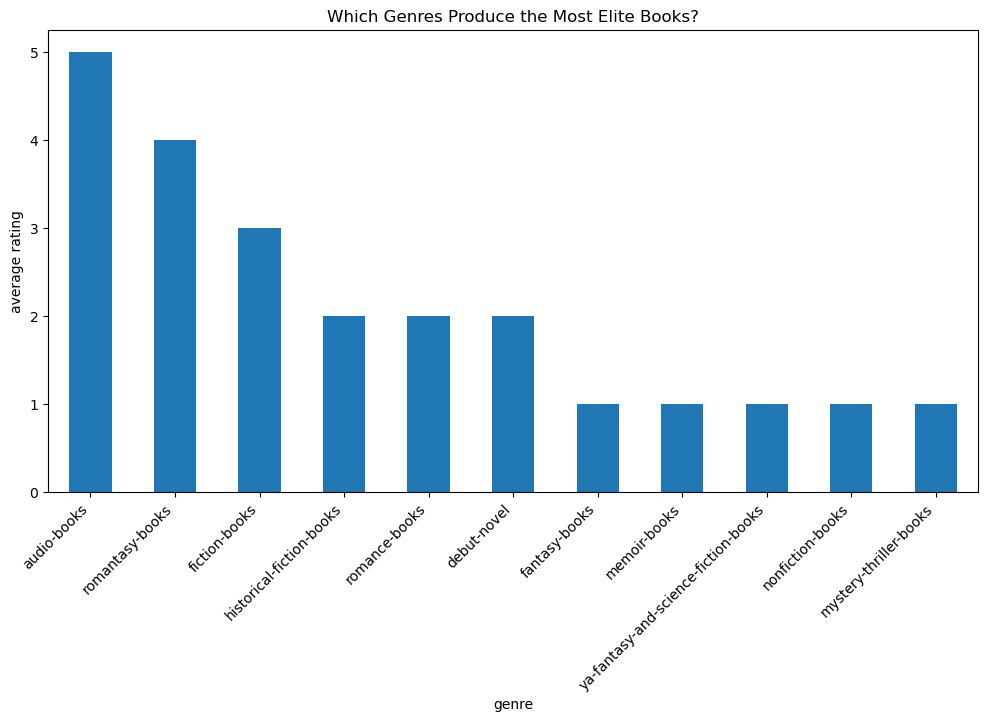

In [18]:
elite_df["genre"].value_counts().plot(kind="bar", figsize=(12, 6))
plt.title("Which Genres Produce the Most Elite Books?")
plt.ylabel("average rating")
plt.xticks(rotation=45, ha="right")
plt.show()

In [19]:
print("Elite books avg pages:", elite_df["pages"].mean().round(2))
print("All books avg pages:", df["pages"].mean().round(2))

# create column to show if book is elite or not
df["elite"] = ((df["rating"] >= rating_threshold) & (df["num_ratings"] >= popularity_threshold))

# format of elite books (hardcover, paperback, etc.)
display(elite_df["format"].value_counts())

# compare elite vs. non-elite books
df.groupby("elite")[["rating", "num_ratings", "pages"]].mean()

Elite books avg pages: 409.05
All books avg pages: 378.07


format
Hardcover         15
Audiobook          5
Paperback          2
Kindle Edition     1
Name: count, dtype: int64

,rating,num_ratings,pages
elite,,,
False,4.022472,74162.524345,375.565385
True,4.357826,340446.782609,409.047619
